# 01. EDA: Анализ и визуализация данных

## Импорт библиотек

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка данных

In [2]:
# Добавляем корневую папку проекта в sys.path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.data_loader import DataLoader

In [3]:
# Загружаем датасет
PROJECT_ROOT = project_root
DATASET_PATH = PROJECT_ROOT / "datasets" / "Credit Risk Data.csv"
KAGGLE_DS = "alexdister/credit-risk-dataset"

df = DataLoader.load(DATASET_PATH, KAGGLE_DS)

## Первичный осмотр структуры данных

In [4]:
print("Первые 5 строк:")
df.head()

Первые 5 строк:


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153440,0.930628,4,0.228103,0


In [5]:
print("Информация о датасете:")
df.info()

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  str    
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  str    
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  str    
 6   loan_grade                  32581 non-null  str    
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  str    
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender             

In [6]:
print("Статистика по всем признакам:")
display(df.describe(include="all"))

Статистика по всем признакам:


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
count,32581,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,...,32581.000000,32581.000000,32581,32581.000000,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
unique,32581,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,...,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST_00001,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,...,NaN,NaN,Full-time,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,...,NaN,NaN,19473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,...,45.407613,-63.805473,NaN,38.501581,0.170553,1.156796e+04,0.345208,8.042018,0.499884,0.505141
std,NaN,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,...,7.644809,46.615580,NaN,16.012441,0.107049,1.306093e+04,0.129406,4.328087,0.259530,0.711745
min,NaN,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,...,29.760400,-123.365600,NaN,12.000000,0.000789,2.252074e+02,0.064502,0.000000,0.050001,0.000000
25%,NaN,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,...,40.712800,-96.797000,NaN,24.000000,0.089655,5.387168e+03,0.251236,4.000000,0.275358,0.000000
50%,NaN,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,...,46.813900,-75.697200,NaN,36.000000,0.148148,8.995071e+03,0.333188,8.000000,0.500289,0.000000
75%,NaN,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,...,51.507400,-3.943600,NaN,60.000000,0.229167,1.456293e+04,0.423142,12.000000,0.725056,1.000000


Типы данных колонок:


str        12
float64     9
int64       8
Name: count, dtype: int64

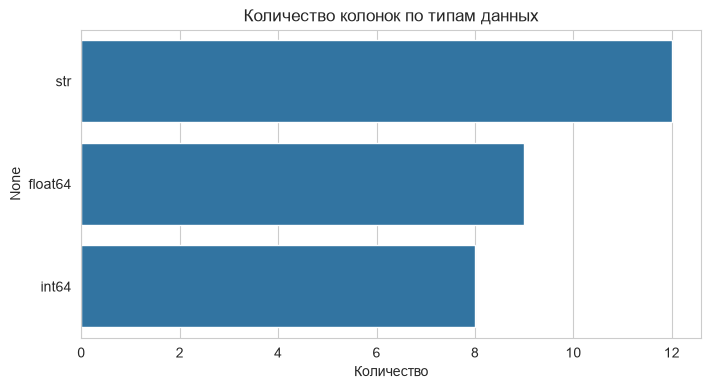

In [7]:
# Распределение типов колонок
dtype_counts = df.dtypes.value_counts()
print("Типы данных колонок:")
display(dtype_counts)

# Визуализация
sns.set_style("whitegrid")
plt.figure(figsize=(8, 4))
sns.barplot(x=dtype_counts.values, y=dtype_counts.index.astype(str))
plt.title("Количество колонок по типам данных")
plt.xlabel("Количество")
plt.show()

In [8]:
# Категориальные признаки
cat_cols = df.select_dtypes(include=["str"]).columns.tolist()
if cat_cols:
    print(f"Категориальные колонки ({len(cat_cols)}):")
    for col in cat_cols:
        uniq = df[col].nunique()
        print(f"  {col}: {uniq} уникальных значений")
        if uniq <= 100:
            print(f"    Примеры: {df[col].unique().tolist()}")
else:
    print("Категориальных колонок не найдено.")

Категориальные колонки (12):
  client_ID: 32581 уникальных значений
  person_home_ownership: 4 уникальных значений
    Примеры: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
  loan_intent: 6 уникальных значений
    Примеры: ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
  loan_grade: 7 уникальных значений
    Примеры: ['D', 'B', 'C', 'A', 'E', 'F', 'G']
  cb_person_default_on_file: 2 уникальных значений
    Примеры: ['Y', 'N']
  gender: 2 уникальных значений
    Примеры: ['Male', 'Female']
  marital_status: 4 уникальных значений
    Примеры: ['Married', 'Divorced', 'Single', 'Widowed']
  education_level: 4 уникальных значений
    Примеры: ['High School', 'Master', 'Bachelor', 'PhD']
  country: 3 уникальных значений
    Примеры: ['Canada', 'UK', 'USA']
  state: 9 уникальных значений
    Примеры: ['Ontario', 'Wales', 'BC', 'New York', 'California', 'Quebec', 'Texas', 'Scotland', 'England']
  city: 18 уникальных значений
    Примеры: ['Toronto', 'Swansea', 

In [9]:
# Числовые признаки, которые ведут себя как категориальные
CATEGORICAL_THRESHOLD = 100

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
potential_cat = []
for col in num_cols:
    n_unique = df[col].nunique()
    if n_unique <= CATEGORICAL_THRESHOLD:
        potential_cat.append((col, n_unique))

print(f"Числовые признаки с <= {CATEGORICAL_THRESHOLD} уникальными значениями (потенциально категориальные):")
for col, n in potential_cat:
    print(f"  {col}: {n} уникальных")

Числовые признаки с <= 100 уникальными значениями (потенциально категориальные):
  person_age: 58 уникальных
  person_emp_length: 36 уникальных
  loan_status: 2 уникальных
  loan_percent_income: 77 уникальных
  cb_person_cred_hist_length: 29 уникальных
  city_latitude: 18 уникальных
  city_longitude: 18 уникальных
  loan_term_months: 4 уникальных
  open_accounts: 16 уникальных
  past_delinquencies: 7 уникальных


In [10]:
# Полная информация по уникальным значениям
unique_info = pd.DataFrame({
    "Тип": df.dtypes,
    "Уникальных": df.nunique(),
    "Доля уникальных (%)": (df.nunique() / len(df) * 100).round(2)
})
unique_info.sort_values("Уникальных", ascending=True, inplace=True)
print("Количество уникальных значений по всем колонкам\n")
display(unique_info)

Количество уникальных значений по всем колонкам



,Тип,Уникальных,Доля уникальных (%)
cb_person_default_on_file,str,2,0.01
gender,str,2,0.01
loan_status,int64,2,0.01
country,str,3,0.01
marital_status,str,4,0.01
education_level,str,4,0.01
employment_type,str,4,0.01
person_home_ownership,str,4,0.01
loan_term_months,int64,4,0.01
loan_intent,str,6,0.02


## Анализ пропусков

In [11]:
# Количество пропусков по каждому признаку
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Кол-во пропусков": missing,
    "Доля (%)": missing_pct
}).sort_values("Кол-во пропусков", ascending=False)
missing_df = missing_df[missing_df["Кол-во пропусков"] > 0]

print("Пропуски по колонкам:")
display(missing_df)

Пропуски по колонкам:


,Кол-во пропусков,Доля (%)
loan_int_rate,3116,9.563856
person_emp_length,895,2.747000


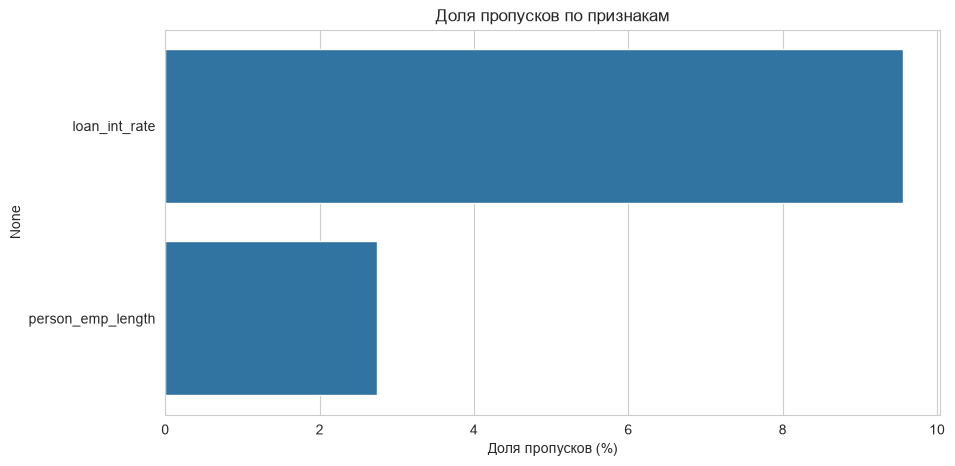

In [12]:
# Визуализация доли пропусков
missing_plot = missing_df.sort_values("Доля (%)", ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_plot["Доля (%)"], y=missing_plot.index)
plt.xlabel("Доля пропусков (%)")
plt.title("Доля пропусков по признакам")
plt.show()

In [13]:
# Анализ связи пропусков с целевой переменной
missing_cols = missing_df.index.tolist()

print("Влияние пропусков на целевую переменную\n")
for col in missing_cols:

    is_missing = df[col].isna()

    mean_with_missing = df.loc[is_missing, "loan_status"].mean()
    mean_without_missing = df.loc[~is_missing, "loan_status"].mean()

    print(f"Признак: {col}")
    print(f"  Доля дефолтов при наличии пропуска: {mean_with_missing:.4f} ({is_missing.sum()} записей)")
    print(f"  Доля дефолтов при отсутствии пропуска: {mean_without_missing:.4f} ({is_missing.sum()} записей)")
    print(f"  Разница: {mean_with_missing - mean_without_missing:.4f}\n")

Влияние пропусков на целевую переменную

Признак: loan_int_rate
  Доля дефолтов при наличии пропуска: 0.2067 (3116 записей)
  Доля дефолтов при отсутствии пропуска: 0.2194 (3116 записей)
  Разница: -0.0127

Признак: person_emp_length
  Доля дефолтов при наличии пропуска: 0.3151 (895 записей)
  Доля дефолтов при отсутствии пропуска: 0.2154 (895 записей)
  Разница: 0.0997



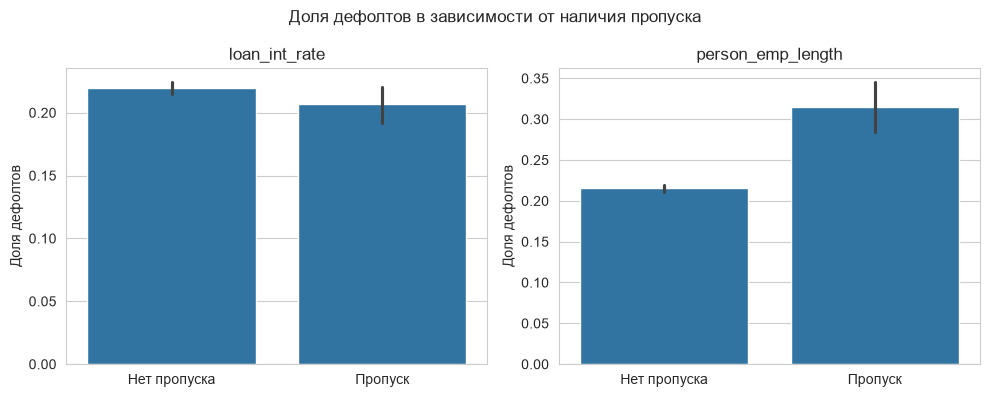

In [14]:
# Визуализация
fig, axes = plt.subplots(1, len(missing_cols), figsize=(10, 4))

for ax, col in zip(axes, missing_cols):
    is_missing = df[col].isnull()
    plot_data = pd.DataFrame({
        "Статус": ["Пропуск" if x else "Нет пропуска" for x in is_missing],
        "loan_status": df["loan_status"]
    })
    sns.barplot(data=plot_data, x="Статус", y="loan_status", ax=ax)
    ax.set_title(f'{col}')
    ax.set_ylabel("Доля дефолтов")
    ax.set_xlabel("")
plt.suptitle("Доля дефолтов в зависимости от наличия пропуска")
plt.tight_layout()
plt.show()

## Анализ дубликатов

In [15]:
# Полные дубликаты строк
print(f"Полных дубликатов строк: {df.duplicated().sum()}")

Полных дубликатов строк: 0


In [16]:
# Дубликаты по client_ID
print(f"Дубликатов по client_ID: {df.duplicated(subset="client_ID").sum()}")

Дубликатов по client_ID: 0


## Анализ целевой переменной

In [17]:
# Распределение классов
target_counts = df["loan_status"].value_counts()
target_pct = df["loan_status"].value_counts(normalize=True) * 100

target_df = pd.DataFrame({
    "Количество": target_counts,
    "Доля (%)": target_pct
})

print("Распределение целевой переменной:")
display(target_df)

Распределение целевой переменной:


,Количество,Доля (%)
loan_status,,
0,25473,78.183604
1,7108,21.816396


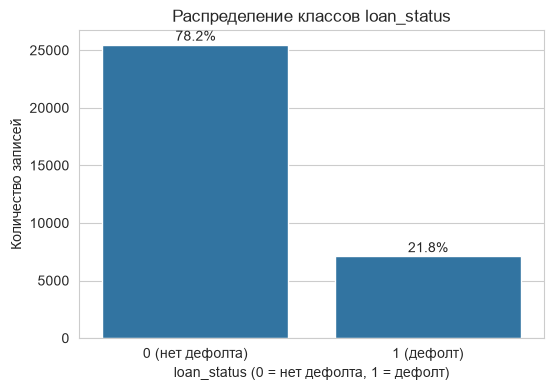

In [18]:
# Визуализация
plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title("Распределение классов loan_status")
plt.xlabel("loan_status (0 = нет дефолта, 1 = дефолт)")
plt.ylabel("Количество записей")
plt.xticks([0, 1], ["0 (нет дефолта)", "1 (дефолт)"])

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 100, f"{target_pct[i]:.1f}%", ha="center", va="bottom")
plt.show()

In [19]:
# Сравнение числовых признаков по классам
num_features = ["credit_utilization_ratio", "other_debt",
                 "debt_to_income_ratio", "loan_to_income_ratio", 
                 "person_income", "loan_amnt",
                 "loan_int_rate", "loan_percent_income",
                 "person_age", "person_emp_length",
                 "cb_person_cred_hist_length", "open_accounts"]

print("Средние значения числовых признаков по классам")

rows = []
for col in num_features:
    means = df.groupby("loan_status")[col].mean()
    diff = means[1] - means[0]
    rows.append({
        "Признак": col,
        "Класс 0": means[0],
        "Класс 1": means[1],
        "Разница": diff
    })

comparison_df = pd.DataFrame(rows)
display(comparison_df)

Средние значения числовых признаков по классам


,Признак,Класс 0,Класс 1,Разница
0,credit_utilization_ratio,0.498885,0.503465,0.004580
1,other_debt,12384.335617,8642.306723,-3742.028894
2,debt_to_income_ratio,0.323231,0.423967,0.100736
3,loan_to_income_ratio,0.148733,0.248750,0.100016
4,person_income,70804.361559,49125.652223,-21678.709336
5,loan_amnt,9237.464178,10850.502954,1613.038777
6,loan_int_rate,10.435999,13.060207,2.624208
7,loan_percent_income,0.148805,0.246889,0.098084
8,person_age,27.807129,27.474676,-0.332453
9,person_emp_length,4.968745,4.137562,-0.831183


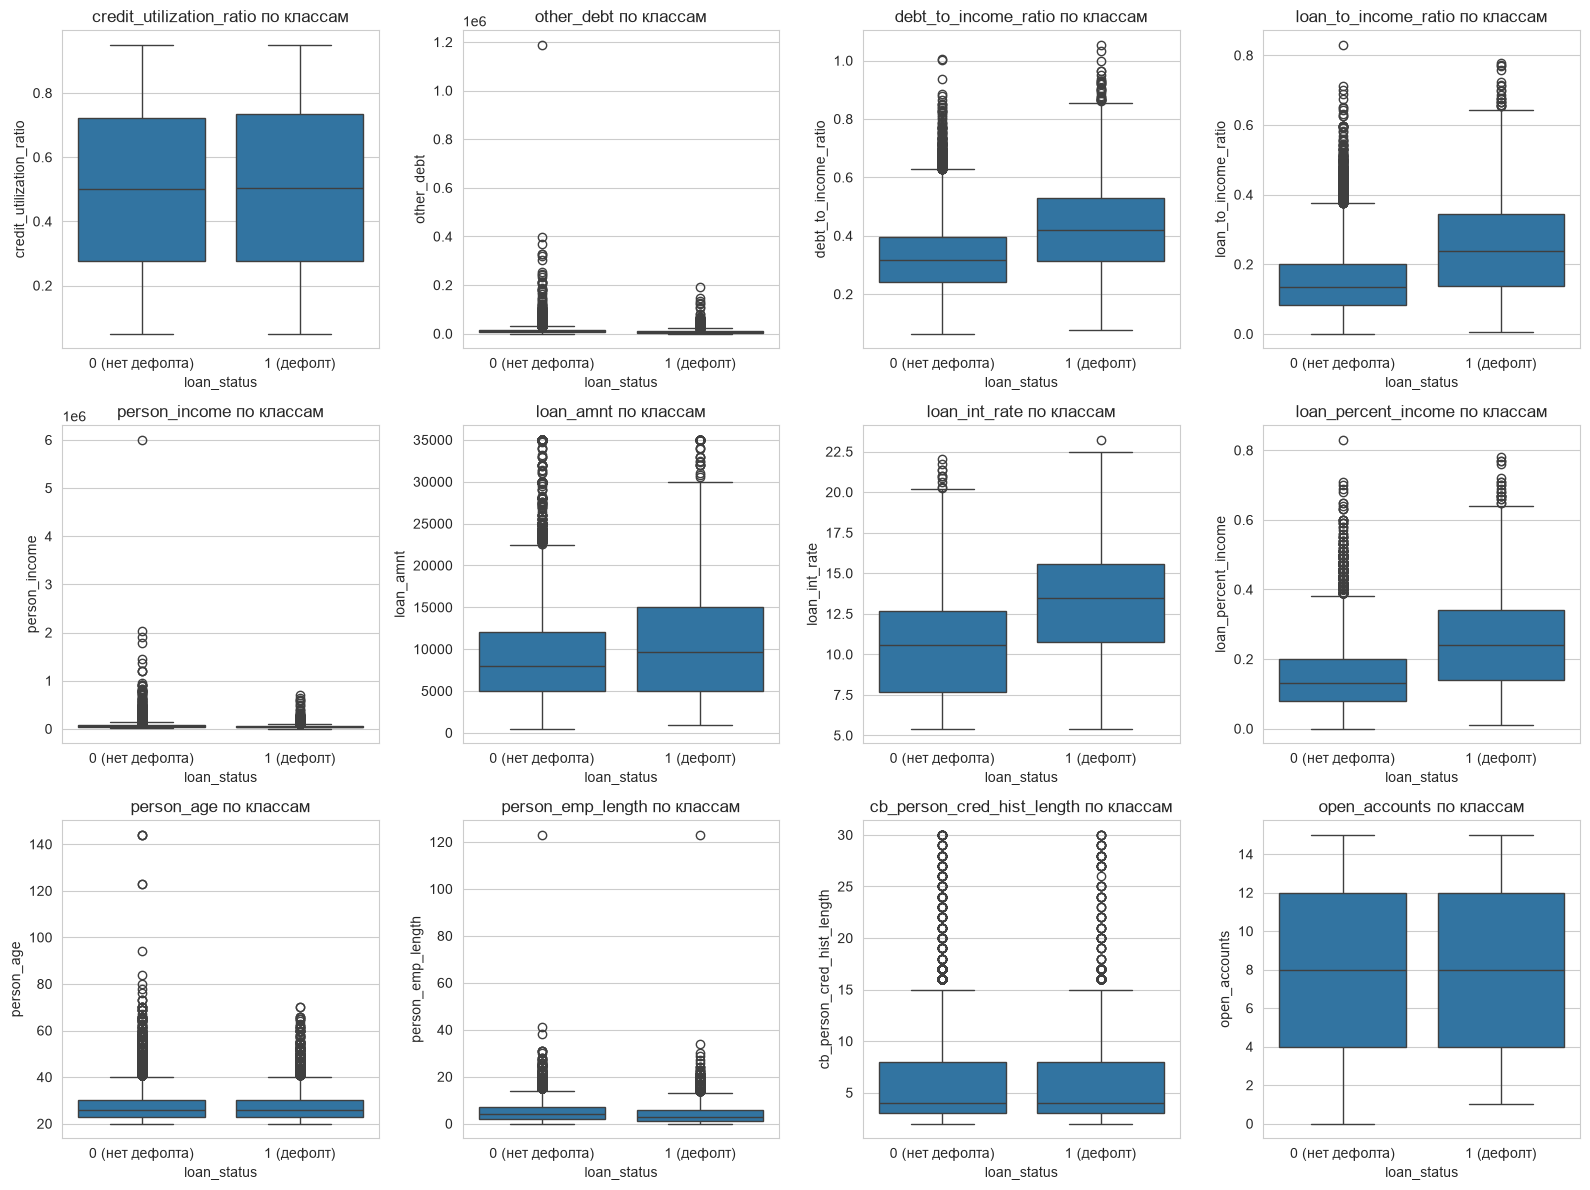

In [20]:
# Визуализация распределения числовых признаков по классам
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(data=df, x="loan_status", y=col, ax=axes[i])
    axes[i].set_title(f"{col} по классам")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["0 (нет дефолта)", "1 (дефолт)"])
plt.tight_layout()
plt.show()

In [21]:
# Таблица долей дефолтов по строковым категориальным признакам
cat_features_str = [
    "cb_person_default_on_file", "gender", "country", "marital_status",
    "education_level", "employment_type", "person_home_ownership",
    "loan_intent", "loan_grade", "state", "city"
]

print("Доля дефолтов по строковым категориальным признакам:")

for col in cat_features_str:
    default_rate = df.groupby(col)["loan_status"].mean().sort_values(ascending=False)
    print(f"\n{col}:")
    display(default_rate.to_frame("Доля дефолтов"))

Доля дефолтов по строковым категориальным признакам:

cb_person_default_on_file:


,Доля дефолтов
cb_person_default_on_file,
Y,0.378068
N,0.183932



gender:


,Доля дефолтов
gender,
Female,0.218692
Male,0.217641



country:


...

,Доля дефолтов
loan_grade,
G,0.984375
F,0.705394
E,0.644191
D,0.590458
C,0.207340
B,0.162760
A,0.099564



state:


,Доля дефолтов
state,
Scotland,0.225055
BC,0.224789
California,0.223430
Texas,0.222284
Ontario,0.218970
England,0.218117
Quebec,0.211934
New York,0.209818
Wales,0.208677



city:


,Доля дефолтов
city,
Vancouver,0.241927
Dallas,0.235949
Edinburgh,0.234643
Los Angeles,0.228509
Manchester,0.225180
Toronto,0.219874
Montreal,0.219011
San Francisco,0.218360
Ottawa,0.218091


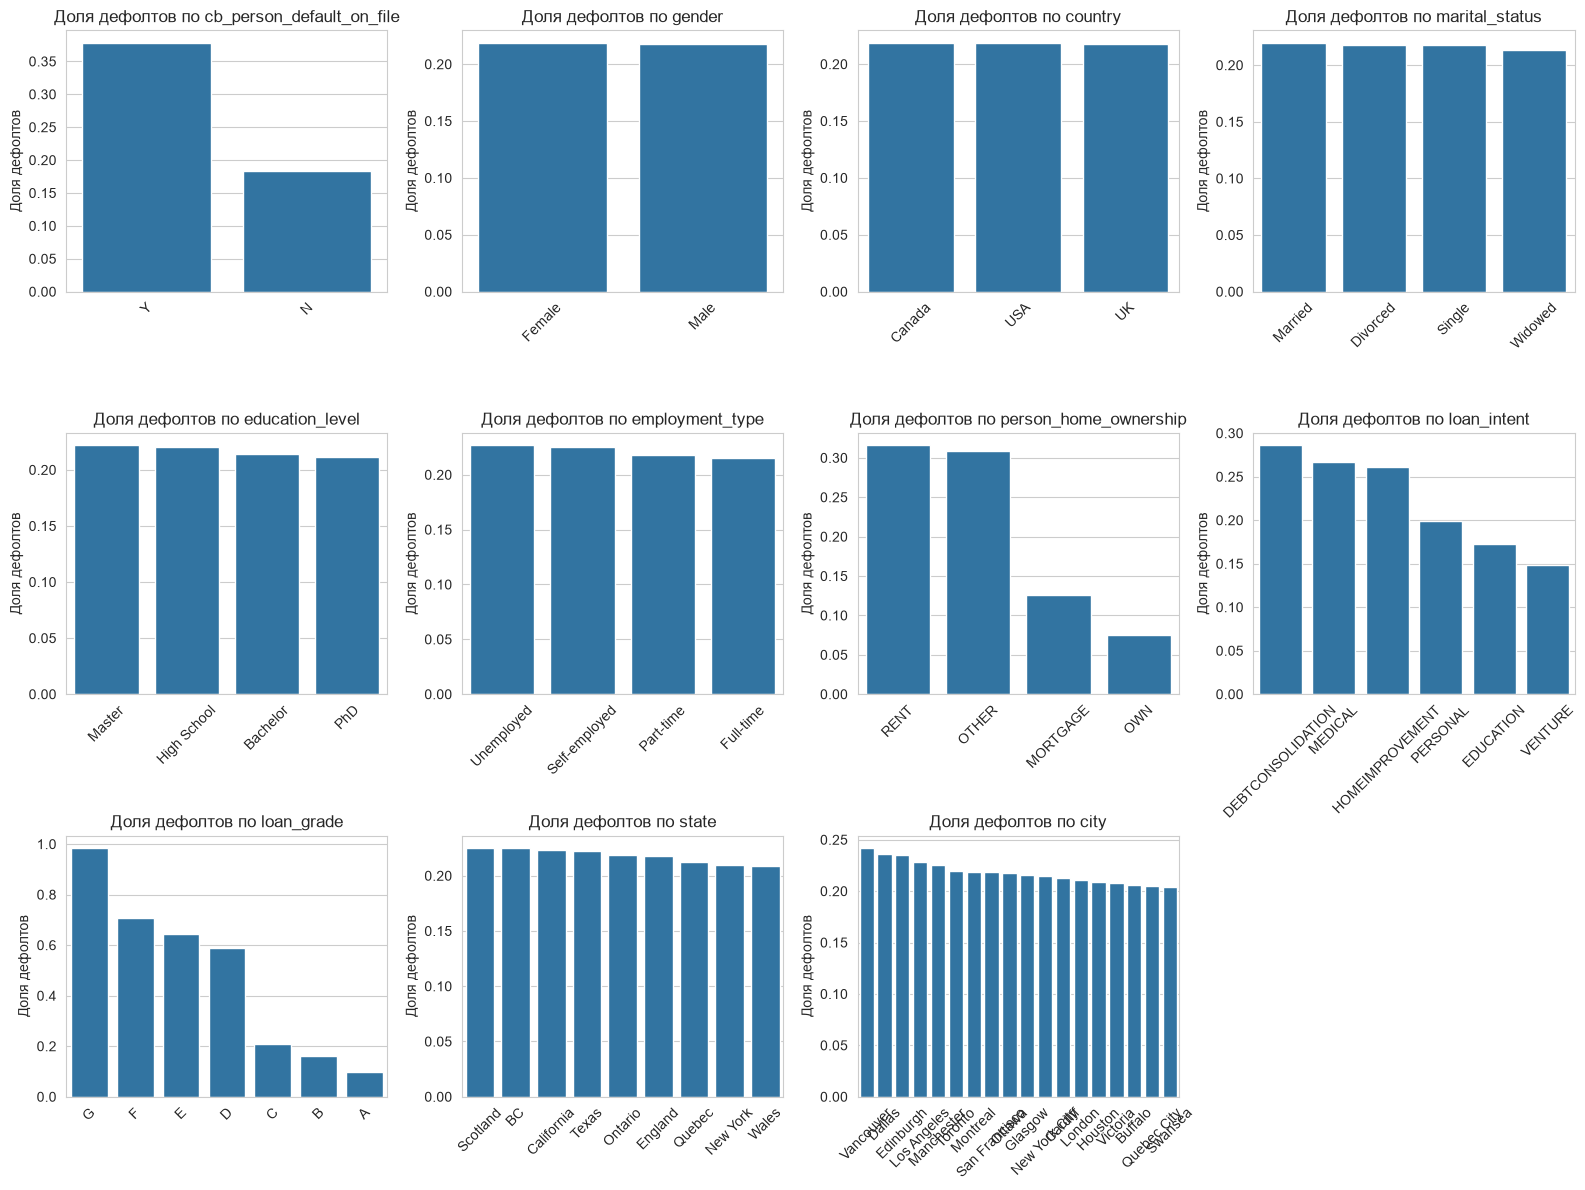

In [22]:
# Визуализация долей дефолтов по строковым категориальным признакам
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features_str):
    default_rate = df.groupby(col)["loan_status"].mean().sort_values(ascending=False)
    sns.barplot(x=default_rate.index, y=default_rate.values, ax=axes[i])
    axes[i].set_title(f"Доля дефолтов по {col}")
    axes[i].set_ylabel("Доля дефолтов")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(cat_features_str), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [23]:
# Таблица долей дефолтов по числовым категориальным признакам
cat_features_num = ["loan_term_months", "past_delinquencies", "city_latitude", "city_longitude"]

print("Доля дефолтов по числовым категориальным признакам:")

for col in cat_features_num:
    default_rate = df.groupby(col)["loan_status"].mean().sort_values(ascending=False)
    print(f"\n{col}:")
    display(default_rate.to_frame("Доля дефолтов"))

Доля дефолтов по числовым категориальным признакам:

loan_term_months:


,Доля дефолтов
loan_term_months,
60,0.223420
24,0.220897
36,0.217630
12,0.199401



past_delinquencies:


,Доля дефолтов
past_delinquencies,
5,0.250000
3,0.232099
4,0.222222
1,0.220165
0,0.217694
2,0.211910
6,0.000000



city_latitude:


,Доля дефолтов
city_latitude,
49.2827,0.241927
32.7767,0.235949
55.9533,0.234643
34.0522,0.228509
53.4808,0.225180
43.6532,0.219874
45.5017,0.219011
37.7749,0.218360
45.4215,0.218091



city_longitude:


,Доля дефолтов
city_longitude,
-123.1207,0.241927
-96.7970,0.235949
-3.1883,0.234643
-118.2437,0.228509
-2.2426,0.225180
-79.3832,0.219874
-73.5673,0.219011
-122.4194,0.218360
-75.6972,0.218091


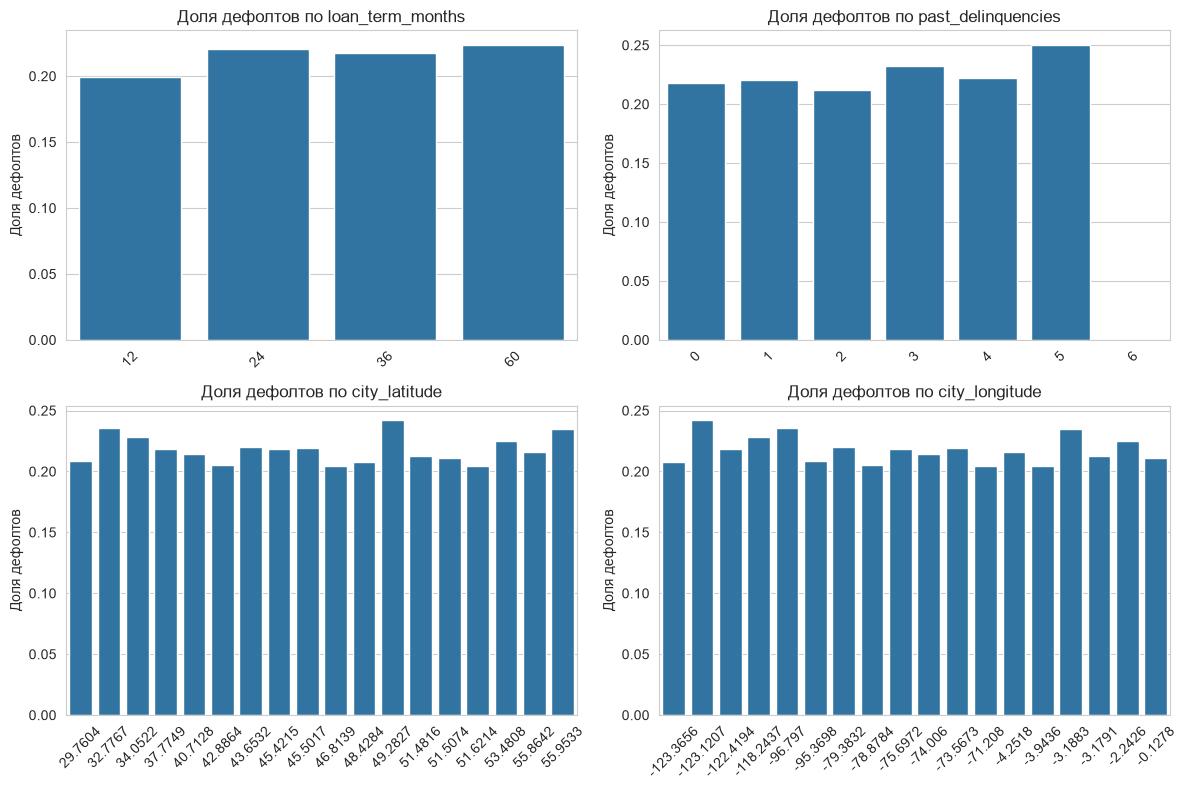

In [24]:
# Визуализация долей дефолтов по числовым категориальным признакам
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features_num):
    default_rate = df.groupby(col)["loan_status"].mean().sort_values(ascending=False)
    sns.barplot(x=default_rate.index, y=default_rate.values, ax=axes[i])
    axes[i].set_title(f"Доля дефолтов по {col}")
    axes[i].set_ylabel("Доля дефолтов")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Анализ числовых признаков

In [25]:
# Описательная статистика числовых признаков
num_features = [
    "credit_utilization_ratio", "other_debt", "debt_to_income_ratio",
    "loan_to_income_ratio", "person_income", "loan_amnt", "loan_int_rate",
    "loan_percent_income", "person_age", "person_emp_length",
    "cb_person_cred_hist_length", "open_accounts"
]

print("Описательная статистика числовых признаков:")
display(df[num_features].describe().T)

Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
credit_utilization_ratio,32581.0,0.499884,0.259530,0.050001,0.275358,0.500289,0.725056,9.499982e-01
other_debt,32581.0,11567.959773,13060.930898,225.207376,5387.168477,8995.070580,14562.930270,1.187999e+06
debt_to_income_ratio,32581.0,0.345208,0.129406,0.064502,0.251236,0.333188,0.423142,1.053888e+00
loan_to_income_ratio,32581.0,0.170553,0.107049,0.000789,0.089655,0.148148,0.229167,8.300000e-01
person_income,32581.0,66074.848470,61983.119168,4000.000000,38500.000000,55000.000000,79200.000000,6.000000e+06
loan_amnt,32581.0,9589.371106,6322.086646,500.000000,5000.000000,8000.000000,12200.000000,3.500000e+04
loan_int_rate,29465.0,11.011695,3.240459,5.420000,7.900000,10.990000,13.470000,2.322000e+01
loan_percent_income,32581.0,0.170203,0.106782,0.000000,0.090000,0.150000,0.230000,8.300000e-01
person_age,32581.0,27.734600,6.348078,20.000000,23.000000,26.000000,30.000000,1.440000e+02
person_emp_length,31686.0,4.789686,4.142630,0.000000,2.000000,4.000000,7.000000,1.230000e+02


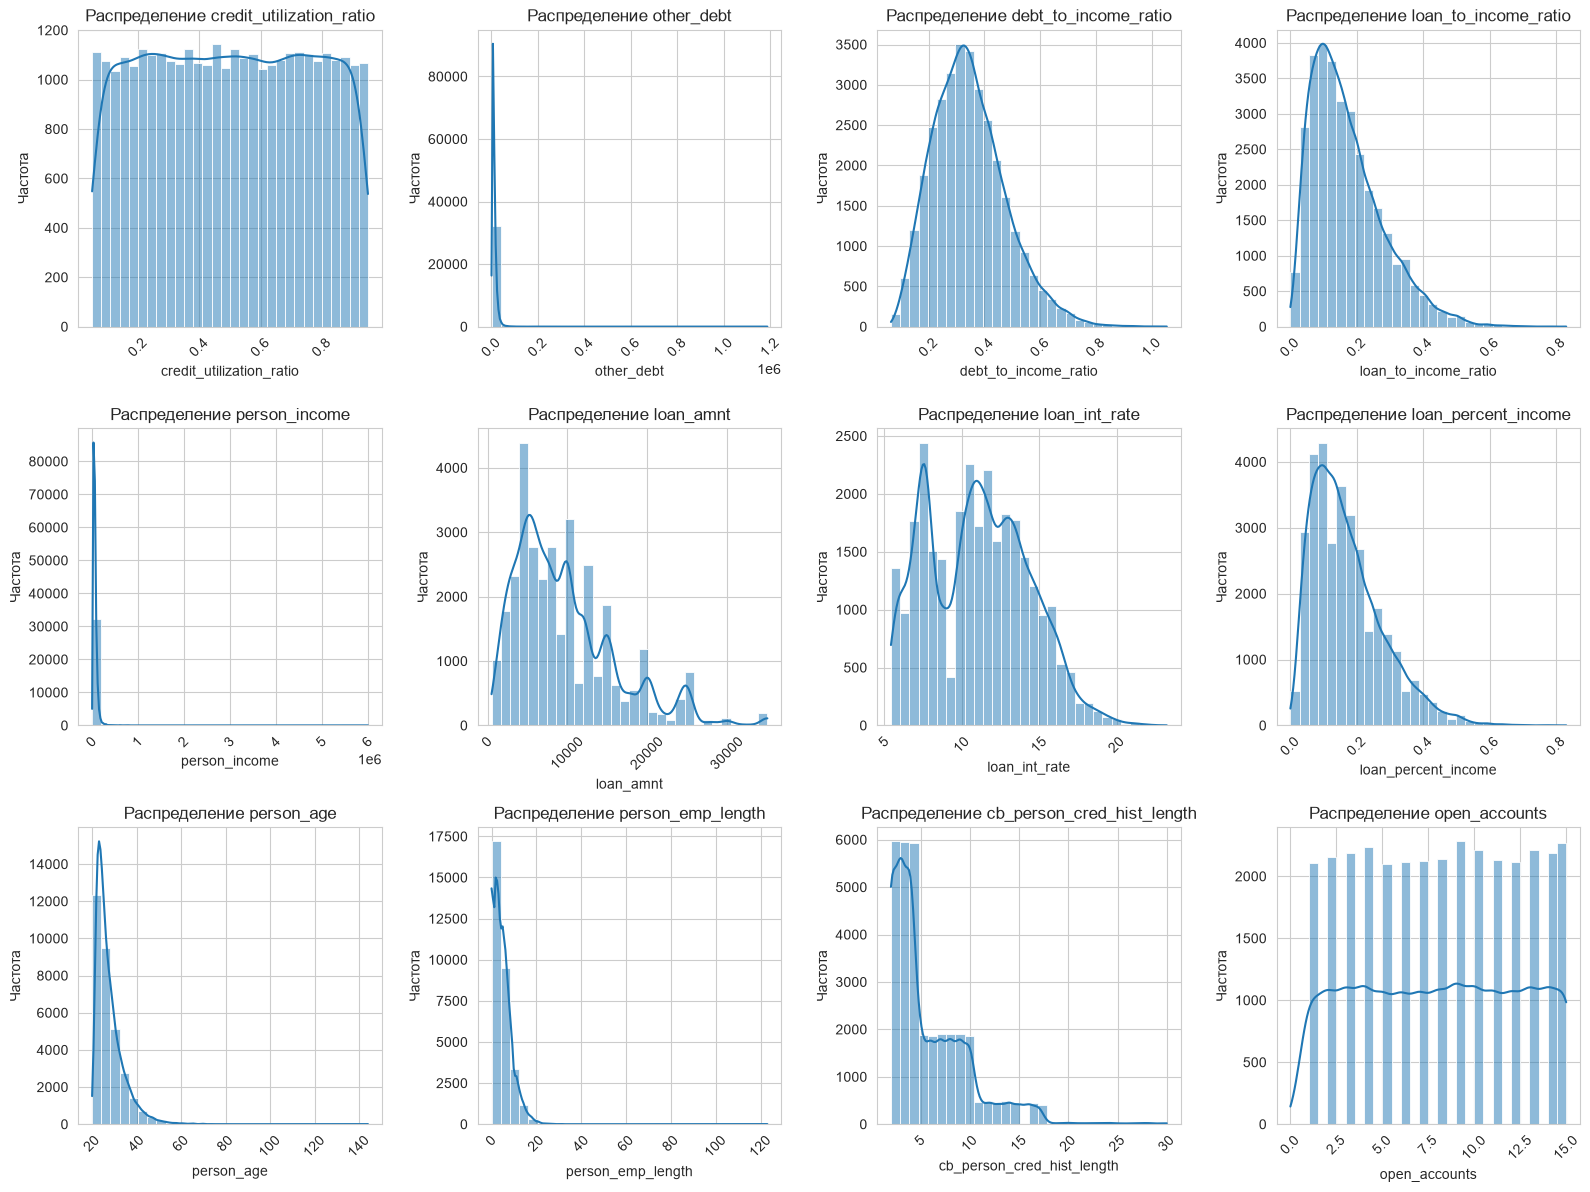

In [26]:
# Гистограммы распределений числовых признаков
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"Распределение {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Частота")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

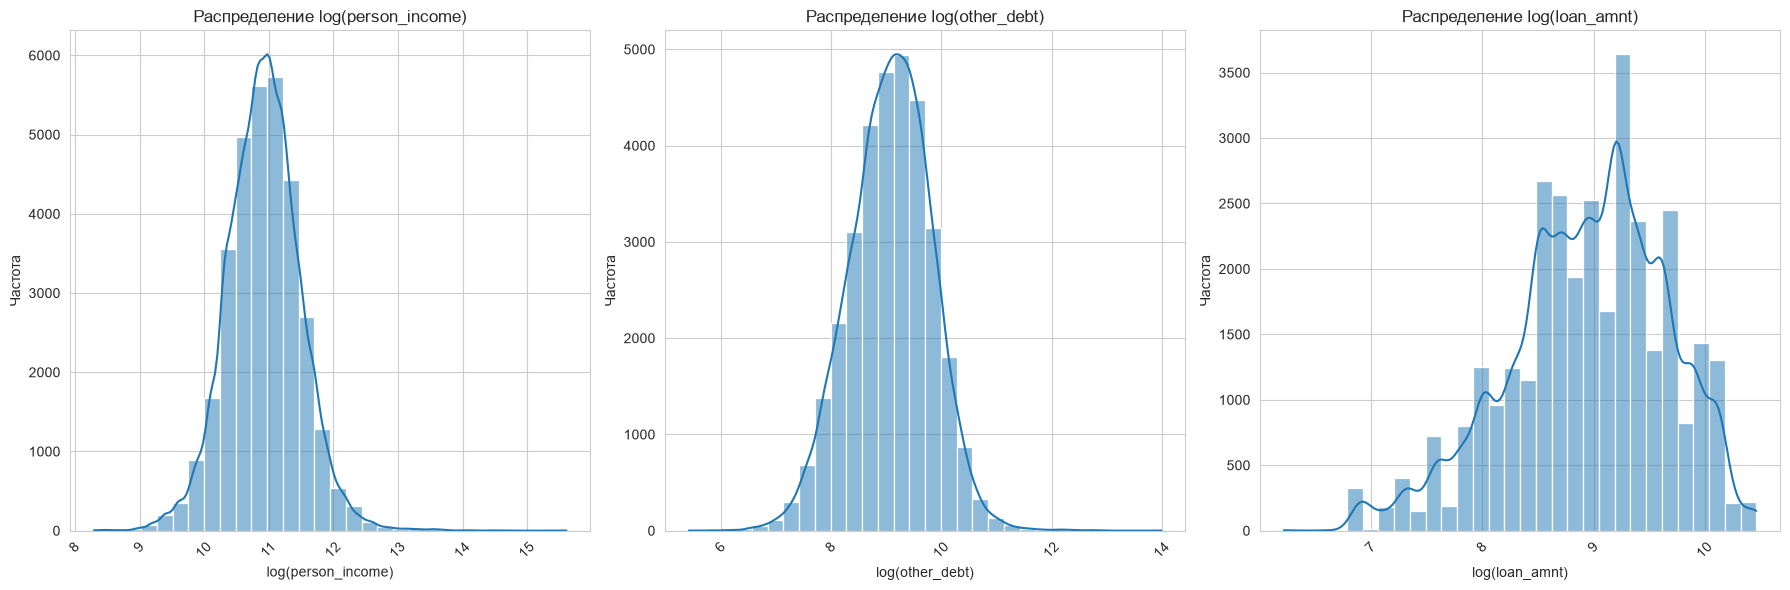

In [27]:
# Визуализация логарифмированных распределений для сильно скошенных признаков
log_features = ["person_income", "other_debt", "loan_amnt"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(log_features):
    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"Распределение log({col})")
    axes[i].set_xlabel(f"log({col})")
    axes[i].set_ylabel("Частота")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

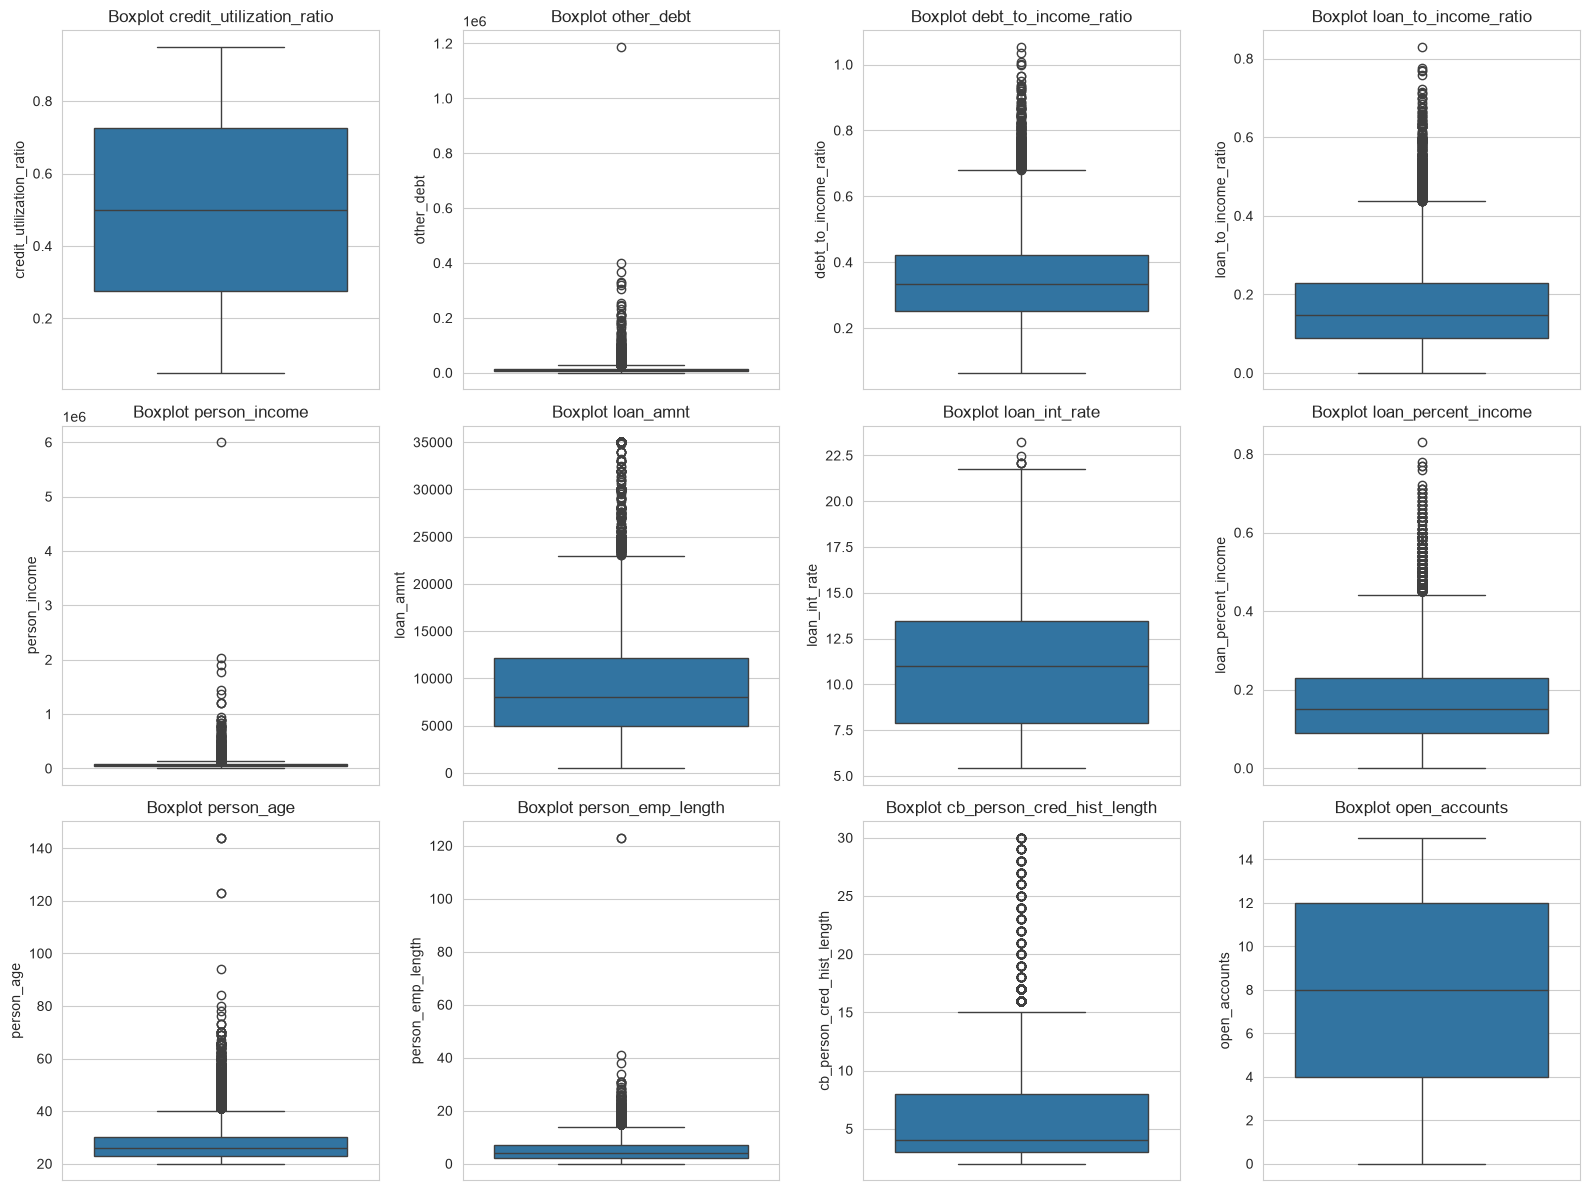

In [28]:
# Boxplot'ы числовых признаков
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

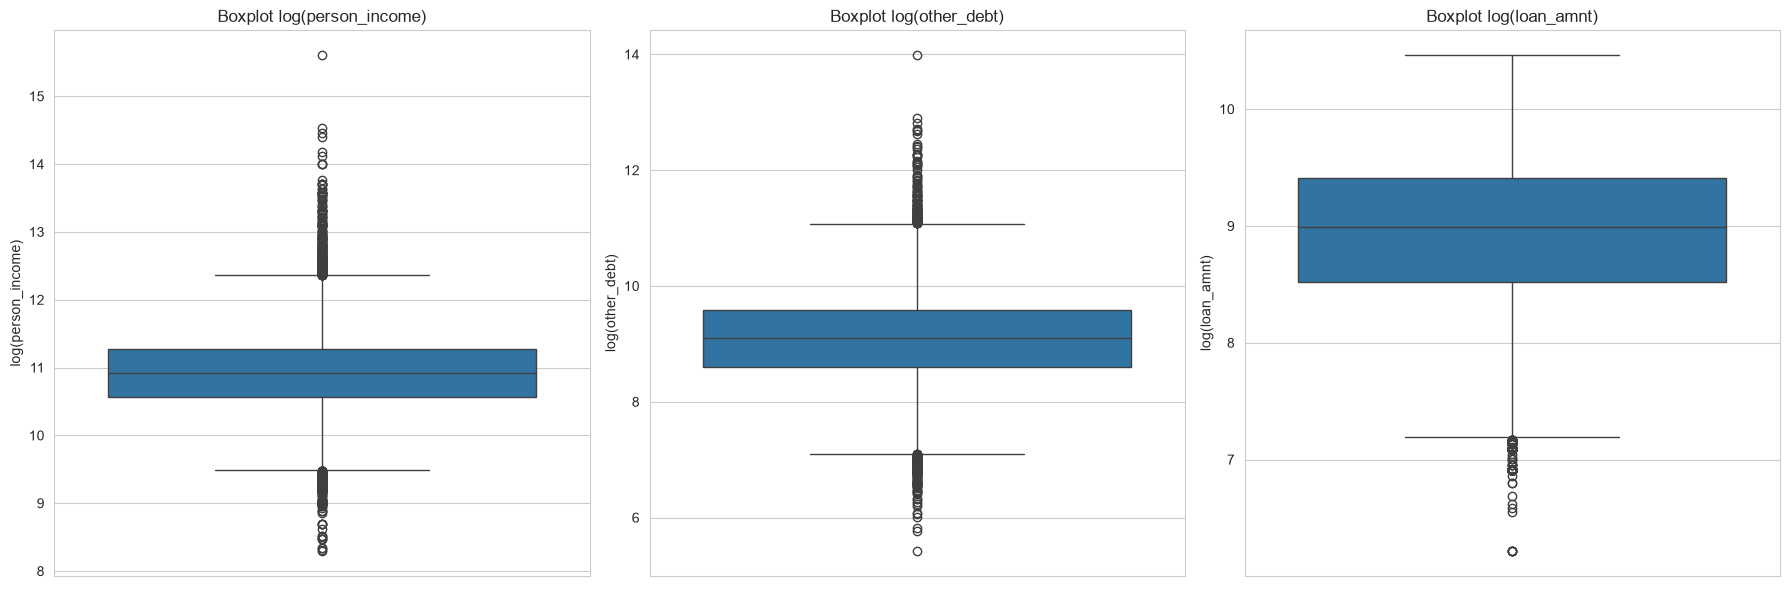

In [29]:
# Анализ выбросов в логарифмированном масштабе для скошенных признаков
log_features = ["person_income", "other_debt", "loan_amnt"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(log_features):
    sns.boxplot(y=np.log1p(df[col]), ax=axes[i])
    axes[i].set_title(f"Boxplot log({col})")
    axes[i].set_ylabel(f"log({col})")

plt.tight_layout()
plt.show()

In [30]:
# Количество выбросов по IQR
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

outliers_count = {}
for col in num_features:
    outliers_count[col] = count_outliers_iqr(df[col])

outliers_df = pd.DataFrame({
    "Признак": list(outliers_count.keys()),
    "Количество выбросов": list(outliers_count.values())
}).sort_values("Количество выбросов", ascending=False)

print("Количество выбросов по IQR-методу:")
display(outliers_df)

Количество выбросов по IQR-методу:


,Признак,Количество выбросов
5,loan_amnt,1689
1,other_debt,1559
8,person_age,1494
4,person_income,1484
10,cb_person_cred_hist_length,1142
9,person_emp_length,853
3,loan_to_income_ratio,733
7,loan_percent_income,651
2,debt_to_income_ratio,463
6,loan_int_rate,6


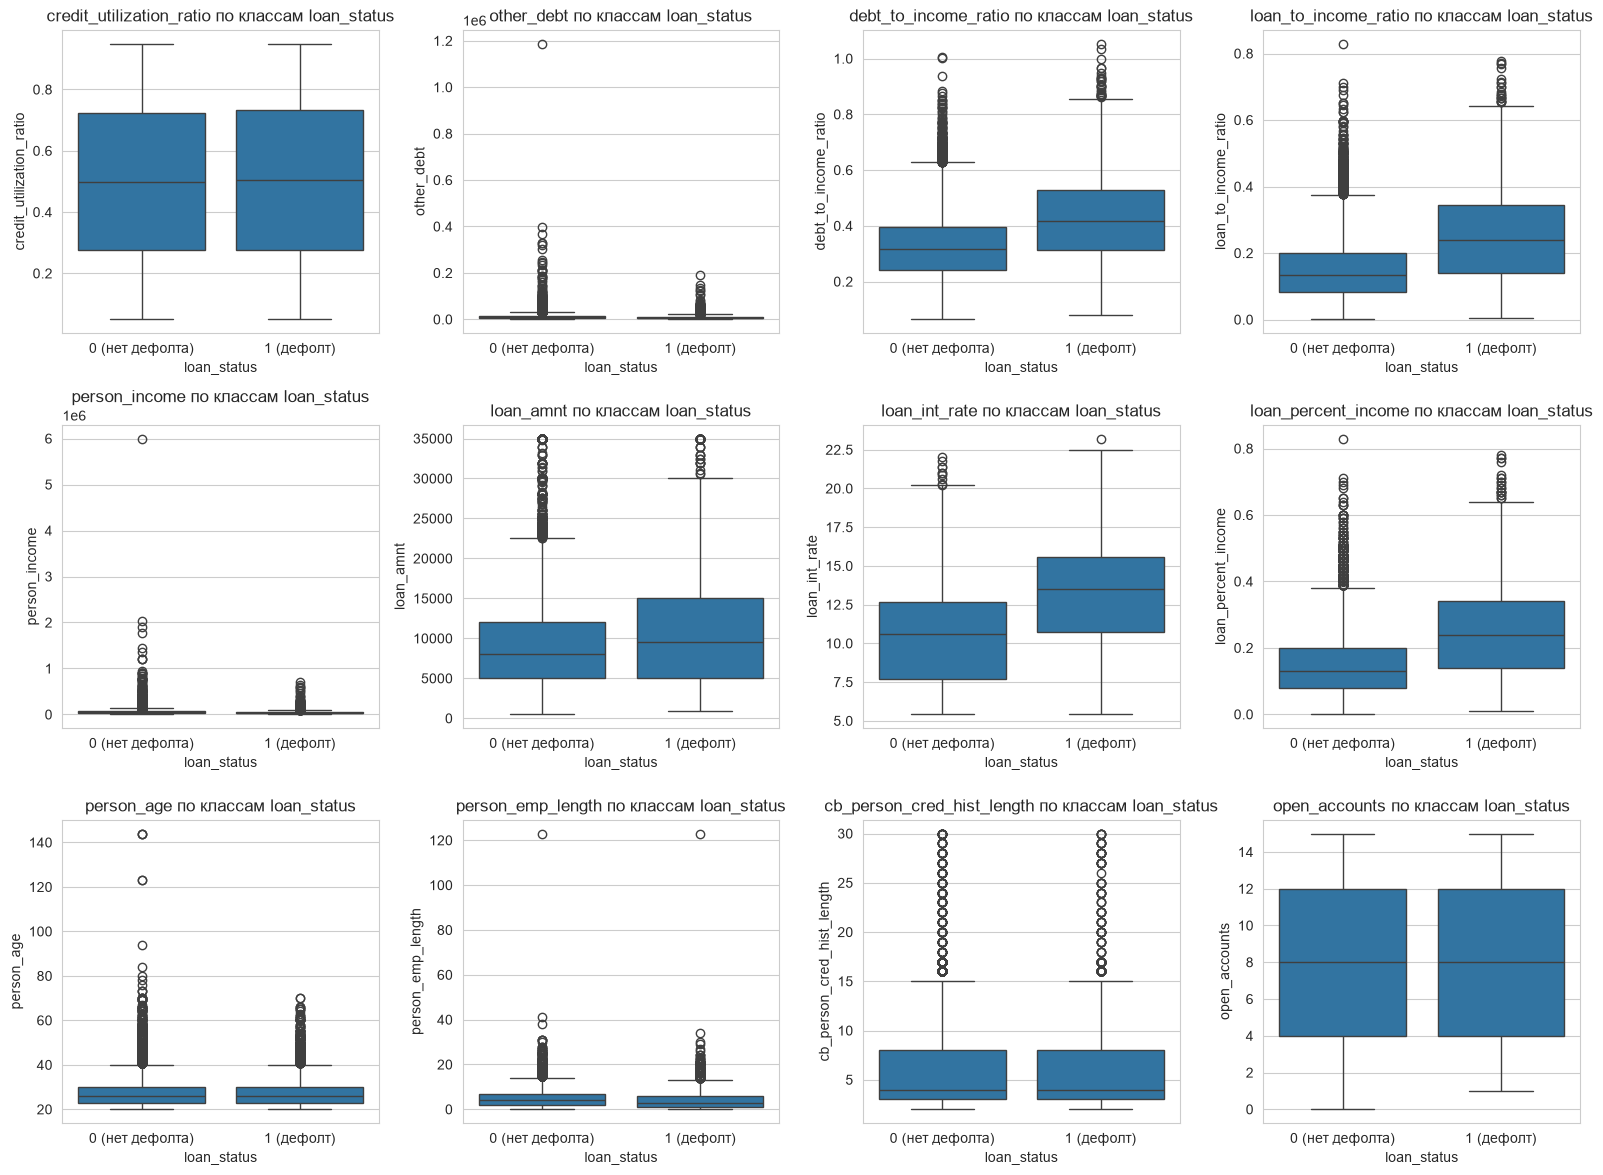

In [31]:
# Взаимосвязь с целевой переменной
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(data=df, x="loan_status", y=col, ax=axes[i])
    axes[i].set_title(f"{col} по классам loan_status")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["0 (нет дефолта)", "1 (дефолт)"])

plt.tight_layout()
plt.show()

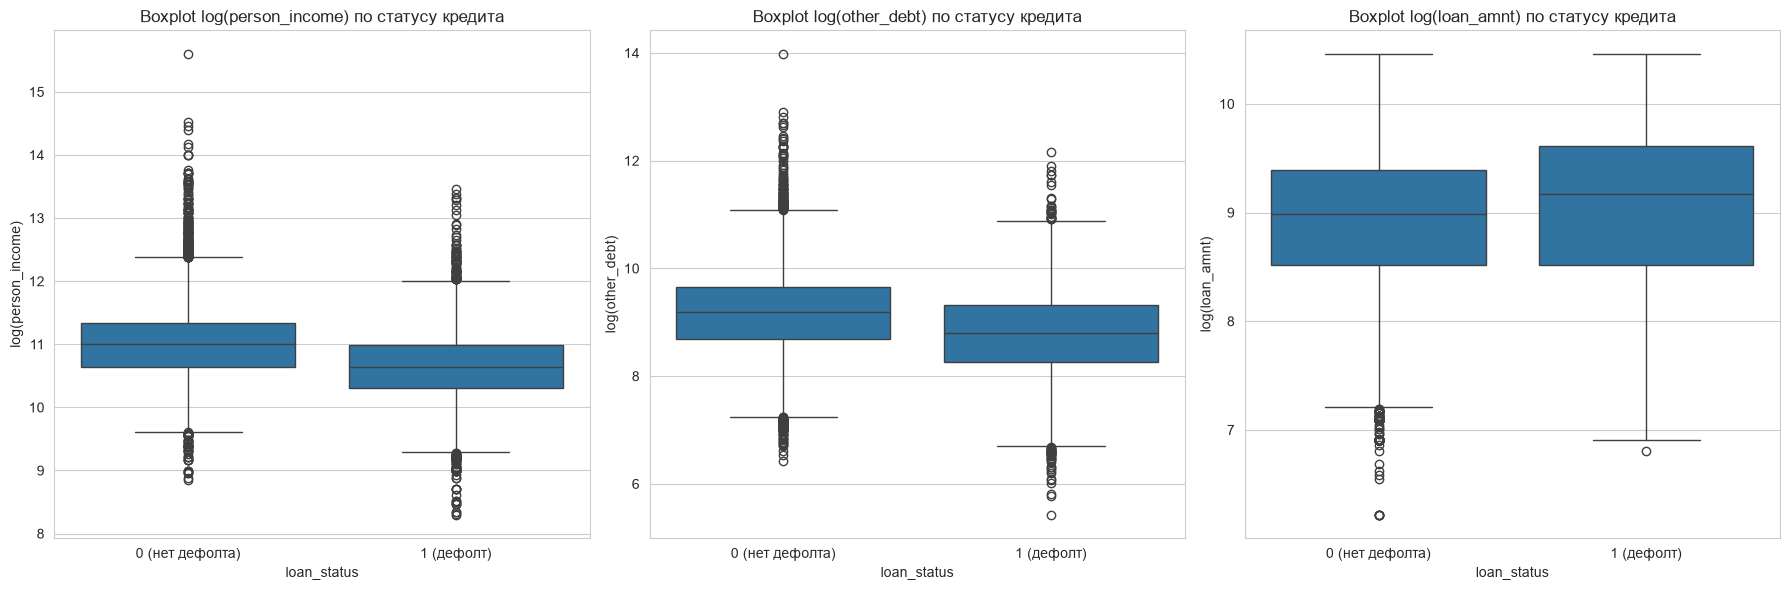

In [32]:
# Сравнение логарифмированных распределений в разрезе целевой переменной
log_features = ["person_income", "other_debt", "loan_amnt"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(log_features):
    sns.boxplot(x='loan_status', y=np.log1p(df[col]), data=df, ax=axes[i])
    axes[i].set_title(f"Boxplot log({col}) по статусу кредита")
    axes[i].set_ylabel(f"log({col})")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["0 (нет дефолта)", "1 (дефолт)"])

plt.tight_layout()
plt.show()

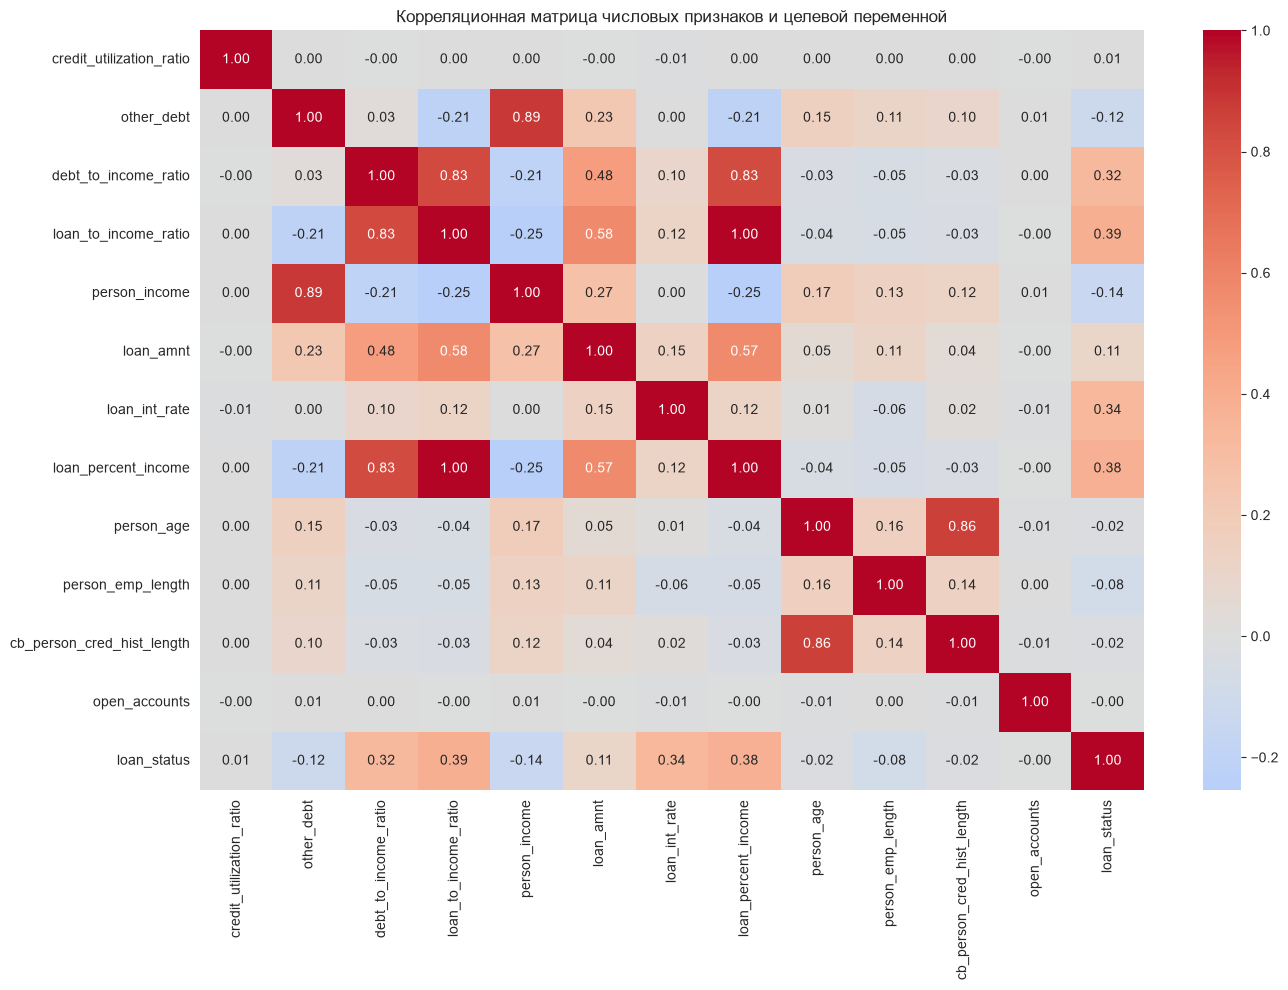

In [33]:
# Тепловая карта корреляций
plt.figure(figsize=(14, 10))
corr_matrix = df[num_features + ["loan_status"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица числовых признаков и целевой переменной")
plt.tight_layout()
plt.show()

In [34]:
# Корреляция признаков с целевой переменной
corr_with_target = corr_matrix["loan_status"].drop("loan_status").sort_values(ascending=False)
print("Корреляция числовых признаков с целевой переменной:")
display(corr_with_target.to_frame("Корреляция с loan_status"))

Корреляция числовых признаков с целевой переменной:


,Корреляция с loan_status
loan_to_income_ratio,0.385873
loan_percent_income,0.379366
loan_int_rate,0.335133
debt_to_income_ratio,0.321503
loan_amnt,0.105376
credit_utilization_ratio,0.007289
open_accounts,-0.002742
cb_person_cred_hist_length,-0.015529
person_age,-0.021629
person_emp_length,-0.082489
